In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# ── Verificar GPU ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Usando GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  GPU no encontrada, usando CPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2026-06-04 13:49:56.232394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 13:49:56.240473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780580996.249536  105789 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780580996.252644  105789 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 13:49:56.263448: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow version: 2.18.1
✅ Usando GPU: /physical_device:GPU:0


In [ ]:
TRAIN_DIR   = '/workspace/dataset/train/'
TEST_DIR    = '/workspace/dataset/test/'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
DROPOUT     = 0.2
PATIENCE    = 5
VAL_SPLIT   = 0.2
SEED        = 123
AUTOTUNE    = tf.data.AUTOTUNE

# Subconjunto para pruebas rápidas (poner None para usar el dataset completo)
TRAIN_SAMPLES = None
TEST_SAMPLES  = None

In [ ]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,   # <-- explícito
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training'
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation'
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_full.class_names
print(f"Clases detectadas: {class_names}")

# Subconjunto para pruebas rápidas
if TRAIN_SAMPLES:
    train_ds = train_ds_full.take(TRAIN_SAMPLES // BATCH_SIZE + 1)
    val_ds   = val_ds_full.take((TRAIN_SAMPLES // 4) // BATCH_SIZE + 1)
else:
    train_ds = train_ds_full
    val_ds   = val_ds_full

if TEST_SAMPLES:
    test_ds = test_ds_full.take(TEST_SAMPLES // BATCH_SIZE + 1)
else:
    test_ds = test_ds_full

print(f"Batches — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 47874 files belonging to 2 classes.
Using 38300 files for training.


I0000 00:00:1780580998.392437  105789 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3508 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


Found 47874 files belonging to 2 classes.
Using 9574 files for validation.
Found 11965 files belonging to 2 classes.
Clases detectadas: ['fake', 'real']
Batches — train: 1197, val: 300, test: 374


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds
    .map(resize_and_augment, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

# Verificación: rango de píxeles
image_batch, labels_batch = next(iter(train_ds))
print(f"Rango de píxeles → min: {np.min(image_batch):.1f}, max: {np.max(image_batch):.1f}")
print(f"Shape del batch: {image_batch.shape}")
print(f"Etiquetas del batch: {labels_batch.numpy()[:8]}")

2026-06-04 13:49:59.844874: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Rango de píxeles → min: 0.0, max: 255.0
Shape del batch: (32, 224, 224, 3)
Etiquetas del batch: [0 0 1 0 1 1 0 1]


In [ ]:
def build_model(img_size: int = IMG_SIZE, dropout_rate: float = DROPOUT,
                learning_rate: float = LR) -> keras.Model:
    """
    ViT con cabeza de clasificación binaria.
    backbone.trainable = False  solo se entrena la cabeza.
    """
    mean = tf.constant([0.485, 0.456, 0.406])
    std  = tf.constant([0.229, 0.224, 0.225])

    inputs = layers.Input(shape=(img_size, img_size, 3), name="images")
    inputs_vit = layers.Lambda(
        lambda x: (tf.cast(x, tf.float32) / 255.0 - mean) / std,
        name="vit_preprocess"
    )(inputs)
    
    backbone_vit = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet21k")
    backbone_vit.trainable = False

    vit_output = backbone_vit({"images": inputs_vit})
    vit_features = vit_output[:, 0, :]

    base_cnn = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    
    base_cnn.trainable = False
    base_cnn_output = base_cnn(inputs, training=False)
    base_cnn_features = layers.GlobalAveragePooling2D()(base_cnn_output)

    combined_model = layers.concatenate([vit_features, base_cnn_features])

    x = layers.BatchNormalization()(combined_model)
    x = layers.Dropout(dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="pred")(x)

    model = keras.Model(inputs, outputs, name="ViT_EfficientNet")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


model = build_model()
model.summary()

trainable_params = sum(
    np.prod(v.shape) for v in model.trainable_weights
)
total_params = sum(
    np.prod(v.shape) for v in model.weights
)
print(f"\nParámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")

Model: "ViT_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_preprocess      │ (None, 224, 224,  │          0 │ images[0][0]      │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vi_t_backbone       │ (None, 197, 768)  │ 85,798,656 │ vit_preprocess[0… │
│ (ViTBackbone)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ images[0][0]      │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ vi_t_backbone[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2048)      │          0 │ get_item[0][0],   │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dropout         │ (None, 2048)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred (Dense)        │ (None, 1)         │      2,049 │ top_dropout[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,858,468 (342.78 MB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 89,852,323 (342.76 MB)


Parámetros entrenables: 6,145 / 89,858,468.0 (0.0%)


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model_cnn_vit_salida.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

with tf.device('/GPU:0'):
    hist = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=callbacks
    )

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(None, 224, 224, 3))']
  warnings.warn(msg)
I0000 00:00:1780581009.500829  105989 service.cc:148] XLA service 0x74db90002410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780581009.500845  105989 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-04 13:50:15.758468: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780581017.256931  105989 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 13:50:18.525155: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_149'

 111/1197 ━━━━━━━━━━━━━━━━━━━━ 2:17 127ms/step - accuracy: 0.6636 - auc: 0.7286 - loss: 0.6672

2026-06-04 13:50:40.961830: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 128/1197 ━━━━━━━━━━━━━━━━━━━━ 2:26 137ms/step - accuracy: 0.6736 - auc: 0.7396 - loss: 0.6528

...

1195/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7885 - auc: 0.8686 - loss: 0.4598

E0000 00:00:1780581253.791395  105989 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780581253.874546  105989 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780581254.068192  105989 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780581254.153108  105989 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780581254.544824  105989 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.7886 - auc: 0.8687 - loss: 0.4597

2026-06-04 13:54:51.358023: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-06-04 13:55:13.563967: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 12 bytes spill stores, 12 bytes spill loads

2026-06-04 13:55:13.834507: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_121', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 13:55:14.058162: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_121', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 13:55:14.062954: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98',


Epoch 1: val_auc improved from None to 0.95139, saving model to best_model_cnn_vit_salida.keras

Epoch 1: finished saving model to best_model_cnn_vit_salida.keras
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 319s 246ms/step - accuracy: 0.8251 - auc: 0.9063 - loss: 0.3941 - val_accuracy: 0.8793 - val_auc: 0.9514 - val_loss: 0.2823 - learning_rate: 0.0010
Epoch 2/100
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8506 - auc: 0.9293 - loss: 0.3425
Epoch 2: val_auc improved from 0.95139 to 0.95401, saving model to best_model_cnn_vit_salida.keras

Epoch 2: finished saving model to best_model_cnn_vit_salida.keras
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 50s 42ms/step - accuracy: 0.8533 - auc: 0.9301 - loss: 0.3408 - val_accuracy: 0.8829 - val_auc: 0.9540 - val_loss: 0.2749 - learning_rate: 0.0010
Epoch 3/100
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8522 - auc: 0.9300 - loss: 0.3422
Epoch 3: val_auc improved from 0.95401 to 0.95403, saving model to best_model_cnn_vit_salida.keras

Epoch 

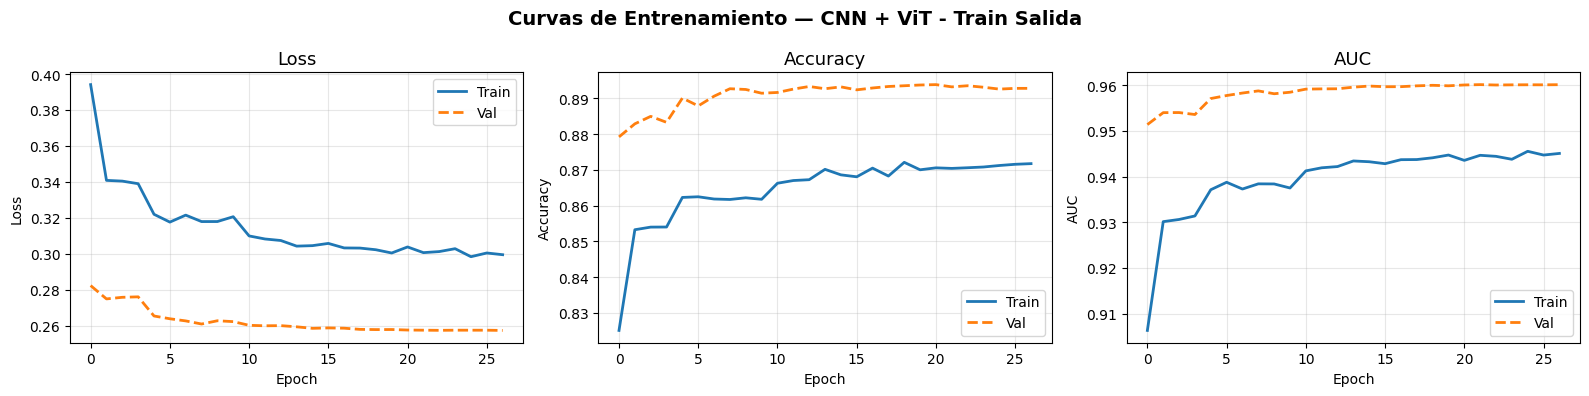

In [7]:
def plot_history(hist):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('loss',     'Loss',     'Loss'),
        ('accuracy', 'Accuracy', 'Accuracy'),
        ('auc',      'AUC',      'AUC'),
    ]
    for ax, (key, title, ylabel) in zip(axes, metrics):
        ax.plot(hist.history[key],     label='Train', linewidth=2)
        ax.plot(hist.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Curvas de Entrenamiento — CNN + ViT - Train Salida', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/workspace/imagenes_metricas_full_dataset/training_curves_cnn_vit_salida_final.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(hist)

In [8]:
print("=" * 45)
print("EVALUACIÓN FINAL SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN FINAL SOBRE TEST SET
 12/374 ━━━━━━━━━━━━━━━━━━━━ 1:33 259ms/step - accuracy: 0.9093 - auc: 0.9645 - loss: 0.2420

2026-06-04 14:16:53.336695: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


139/374 ━━━━━━━━━━━━━━━━━━━━ 40s 174ms/step - accuracy: 0.8910 - auc: 0.9577 - loss: 0.2649

Corrupt JPEG data: premature end of data segment


337/374 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.8874 - auc: 0.9565 - loss: 0.2683

2026-06-04 14:17:48.472441: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


373/374 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8872 - auc: 0.9564 - loss: 0.2684

2026-06-04 14:17:55.660020: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 14:17:55.769354: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 132 bytes spill stores, 132 bytes spill loads

2026-06-04 14:17:55.841874: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 14:17:55.879206: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 884 bytes spill stores, 884 bytes spill loads

2026-06-04 14:17:56.144711: I external/local_xla/xla/stream_executor

374/374 ━━━━━━━━━━━━━━━━━━━━ 71s 190ms/step - accuracy: 0.8854 - auc: 0.9560 - loss: 0.2693

Loss:     0.2693
Accuracy: 0.8854  (88.54%)
AUC:      0.9560


In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)


Distribución y_true: [5970 5995]
Distribución y_pred: [5977 5988]


2026-06-04 14:18:21.513880: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


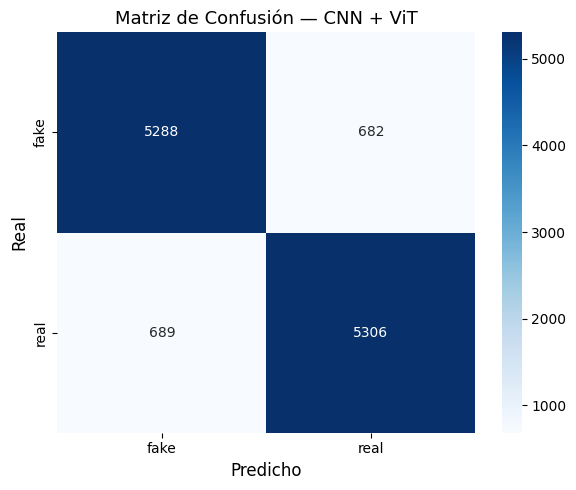


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.88      0.89      0.89      5970
        real       0.89      0.89      0.89      5995

    accuracy                           0.89     11965
   macro avg       0.89      0.89      0.89     11965
weighted avg       0.89      0.89      0.89     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — CNN + ViT', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_cnn_vit_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


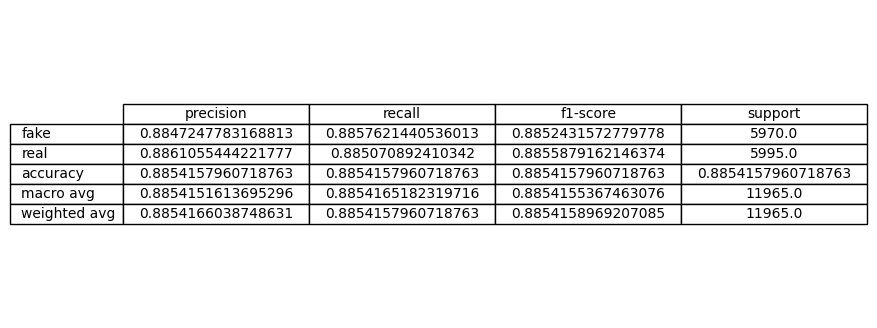

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

# Dibujar la tabla
table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_cnn_vit_salida_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

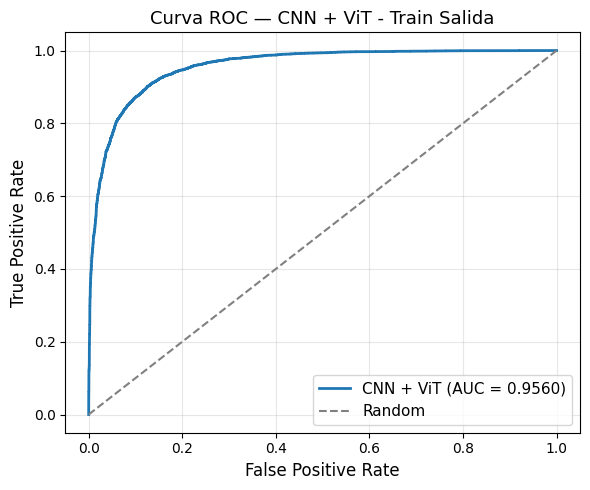

AUC final (test completo): 0.9560


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'CNN + ViT (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — CNN + ViT - Train Salida', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_cnn_vit_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")